In [27]:
import json, os
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
import pandas as pd


FILE_URL = 'enriched_data.json'
GRAPH_FILE = 'repo_collab_graph.pkl'


## Creating the graph

In [28]:
if os.path.exists(GRAPH_FILE):
    print(f"Loading graph from {GRAPH_FILE}")
    with open(GRAPH_FILE, "rb") as f:
        G = pickle.load(f)
    print(f"Loaded graph from {GRAPH_FILE}")

else:
    with open(FILE_URL, "r") as f:
        data = f.read()
    data = json.loads(data)

    G = nx.Graph()

    # STEP 1: Add all nodes first
    for key in list(data.keys()):
        language = data[key].get("language")
        if language is None:
            continue
        G.add_node(
            key,
            language=language,
            stars=data[key].get("stargazers_count"),
            forks=data[key].get("forks_count"),
            authors=set(data[key].get("authors", [])),  # Use set for faster lookup
            num_collab=data[key].get("number_of_collaborators", 0),
        )

    # STEP 2: Add edges (only once, after all nodes exist)
    repos = list(G.nodes())
    for i in range(len(repos)):
        for j in range(i + 1, len(repos)):
            r1, r2 = repos[i], repos[j]
            common = G.nodes[r1]["authors"] & G.nodes[r2]["authors"]  # Set intersection
            if common:
                G.add_edge(r1, r2, weight=len(common), shared=list(common))


# Find isolates
isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")


G_connected = G.copy()
G_connected.remove_nodes_from(isolates)

with open('github_network_s1.pickle', 'wb') as f:
    pickle.dump(G_connected, f)


Loading graph from repo_collab_graph.pkl
Loaded graph from repo_collab_graph.pkl
Isolated nodes: 10


## Plotting degree distribution

Nodes: 129, Edges: 3797
Max degree: 103, Mean degree: 54.63
Top 10 nodes by degree:
  nodejs/node: 103
  axios/axios: 103
  facebook/react: 100
  neovim/neovim: 99
  tauri-apps/tauri: 98
  supabase/supabase: 97
  denoland/deno: 96
  rust-lang/rust: 95
  python/cpython: 95
  microsoft/generative-ai-for-beginners: 94


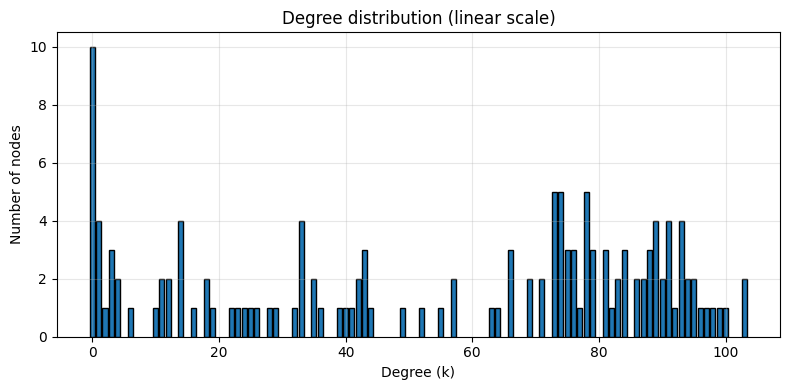

In [29]:
degrees = [d for _, d in G.degree()]
if len(degrees) == 0:
    raise RuntimeError("Graph `G` has no nodes/edges.")

deg_count = Counter(degrees)
deg_items = sorted(deg_count.items())    # list of (degree, count)
ks, counts = zip(*deg_items)
ks = np.array(ks)
counts = np.array(counts)

# Basic stats
print(f"Nodes: {G_connected.number_of_nodes()}, Edges: {G_connected.number_of_edges()}")
print(f"Max degree: {ks.max()}, Mean degree: {np.mean(degrees):.2f}")
print("Top 10 nodes by degree:")
top10 = sorted(G_connected.degree(), key=lambda x: x[1], reverse=True)[:10]
for node, deg in top10:
    print(f"  {node}: {deg}")

# 1) Linear bar histogram of degree counts
plt.figure(figsize=(8,4))
plt.bar(ks, counts, width=0.8, color='C0', edgecolor='k')
plt.xlabel('Degree (k)')
plt.ylabel('Number of nodes')
plt.title('Degree distribution (linear scale)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
n = G_connected.number_of_nodes()
avg_degree = np.mean([d for n, d in G_connected.degree()])

# In BA model: average degree ≈ 2m (for large n)
m = int(avg_degree / 2)

print(f"Your network: {n} nodes, avg degree: {avg_degree:.2f}")
print(f"BA parameters: n={n}, m={m}")

# Generate comparable BA model
G_ba = nx.barabasi_albert_graph(n, m)

Your network: 129 nodes, avg degree: 58.87
BA parameters: n=129, m=29


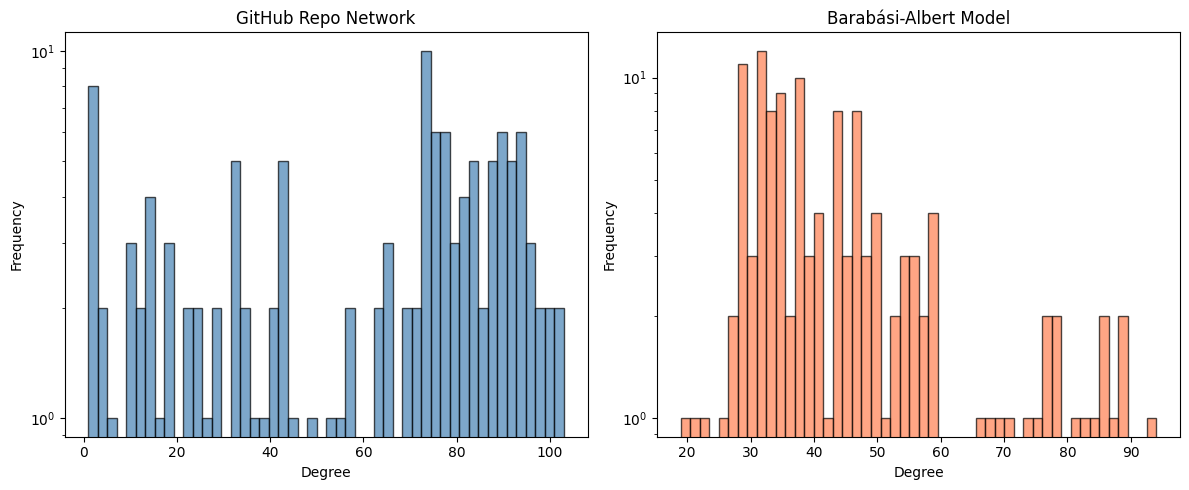

In [31]:
# Get degree sequences
degrees_real = [d for n, d in G_connected.degree()]
degrees_ba = [d for n, d in G_ba.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Your network
ax1.hist(degrees_real, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Frequency')
ax1.set_title('GitHub Repo Network')
ax1.set_yscale('log')

# BA model
ax2.hist(degrees_ba, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Frequency')
ax2.set_title('Barabási-Albert Model')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('degree_comparison_ba.png')
plt.show()

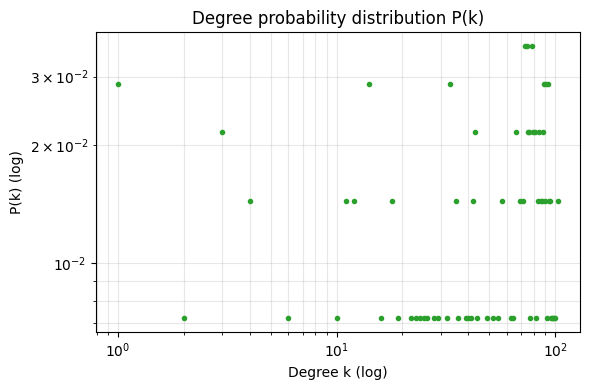

In [32]:
nonzero = ks > 0
k_nz = ks[nonzero]
c_nz = counts[nonzero]

plt.figure(figsize=(6,4))
p_k = counts / counts.sum()
plt.loglog(ks[nonzero], p_k[nonzero], marker='.', linestyle='none', color='C2')
plt.xlabel('Degree k (log)')
plt.ylabel('P(k) (log)')
plt.title('Degree probability distribution P(k)')
plt.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Stats:

In [33]:
degrees = [d for n, d in G_connected.degree()]
print(f"\n=== Connected Component ===")
print(f"Nodes: {G_connected.number_of_nodes()}")
print(f"Edges: {G_connected.number_of_edges()}")
print(f"Avg degree: {np.mean(degrees):.2f}")
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")
print(f"Std deviation: {np.std(degrees):.2f}")

# Clustering coefficient
#print(f"Avg clustering: {nx.average_clustering(G_connected):.4f}")


=== Connected Component ===
Nodes: 129
Edges: 3797
Avg degree: 58.87
Max degree: 103
Min degree: 1
Std deviation: 31.43


In [34]:
# Calculate centrality measures
degree_cent = nx.degree_centrality(G_connected)
print(f"Calculated degree centrality for {len(degree_cent)} nodes.")
#betweenness_cent = nx.betweenness_centrality(G_connected)
#print(f"Calculated betweenness centrality for {len(betweenness_cent)} nodes.")
eigenvector_cent = nx.eigenvector_centrality(G_connected, max_iter=1000)
#print(f"Calculated eigenvector centrality for {len(eigenvector_cent)} nodes.")
#closeness_cent = nx.closeness_centrality(G_connected)
#print(f"Calculated closeness centrality for {len(closeness_cent)} nodes.")

# Store in a DataFrame for easy analysis
centrality_df = pd.DataFrame({
    'repo': list(G_connected.nodes()),
    'degree': [degree_cent[n] for n in G_connected.nodes()],
    #'betweenness': [betweenness_cent[n] for n in G_connected.nodes()],
    'eigenvector': [eigenvector_cent[n] for n in G_connected.nodes()],
    #'closeness': [closeness_cent[n] for n in G_connected.nodes()],
    'stars': [G_connected.nodes[n].get('stars', 0) for n in G_connected.nodes()],
    'forks': [G_connected.nodes[n].get('forks', 0) for n in G_connected.nodes()],
    'language': [G_connected.nodes[n].get('language', 'Unknown') for n in G_connected.nodes()],
})

Calculated degree centrality for 129 nodes.


In [35]:
def top_by_centrality(df, measure, n=10):
    print(f"\n=== Top {n} by {measure.upper()} ===")
    top = df.nlargest(n, measure)[['repo', measure, 'stars', 'language']]
    for i, row in top.iterrows():
        print(f"{row['repo']:40} | {measure}: {row[measure]:.4f} | ⭐ {row['stars']:,}")

top_by_centrality(centrality_df, 'degree')
#top_by_centrality(centrality_df, 'betweenness')
top_by_centrality(centrality_df, 'eigenvector')
#top_by_centrality(centrality_df, 'closeness')


=== Top 10 by DEGREE ===
nodejs/node                              | degree: 0.8047 | ⭐ 114,638
axios/axios                              | degree: 0.8047 | ⭐ 108,345
facebook/react                           | degree: 0.7812 | ⭐ 241,413
neovim/neovim                            | degree: 0.7734 | ⭐ 94,820
tauri-apps/tauri                         | degree: 0.7656 | ⭐ 99,759
supabase/supabase                        | degree: 0.7578 | ⭐ 94,344
denoland/deno                            | degree: 0.7500 | ⭐ 105,491
rust-lang/rust                           | degree: 0.7422 | ⭐ 108,356
python/cpython                           | degree: 0.7422 | ⭐ 70,176
microsoft/generative-ai-for-beginners    | degree: 0.7344 | ⭐ 102,829

=== Top 10 by EIGENVECTOR ===
nodejs/node                              | eigenvector: 0.1256 | ⭐ 114,638
axios/axios                              | eigenvector: 0.1249 | ⭐ 108,345
neovim/neovim                            | eigenvector: 0.1242 | ⭐ 94,820
tauri-apps/tauri       

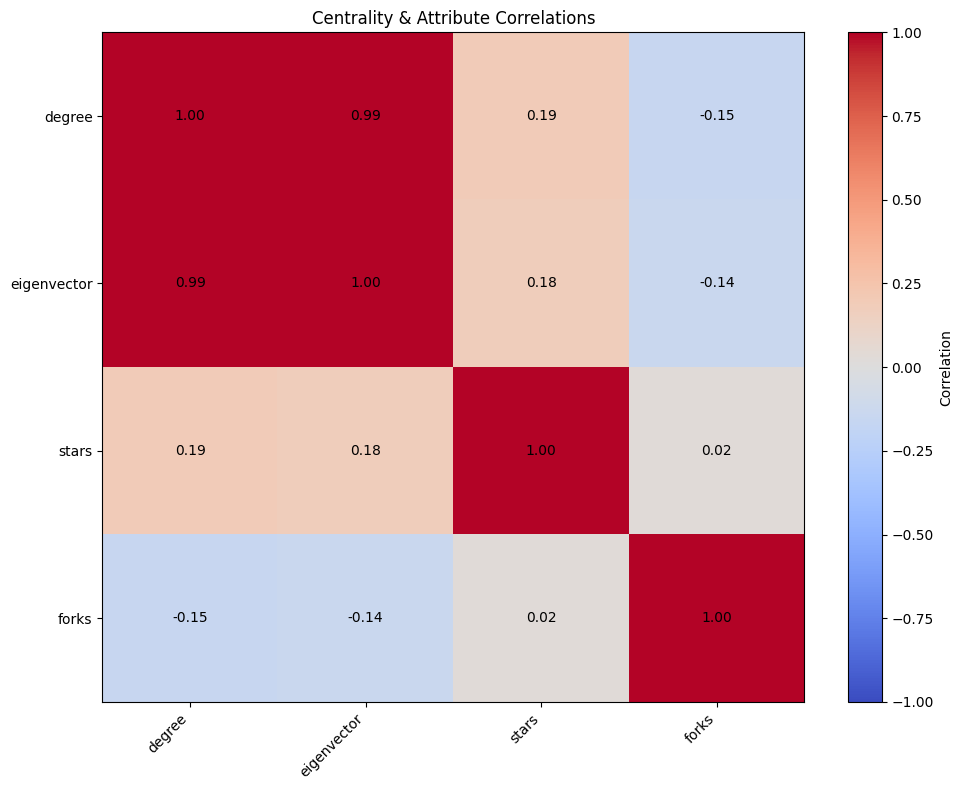

In [36]:
# Correlation matrix
correlation_cols = ['degree', 'eigenvector', 'stars', 'forks']
corr_matrix = centrality_df[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45, ha='right')
plt.yticks(range(len(correlation_cols)), correlation_cols)

# Add correlation values
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', fontsize=10)

plt.title('Centrality & Attribute Correlations')
plt.tight_layout()
plt.savefig('centrality_correlation.png')
plt.show()

Degree Assortativity: -0.0150


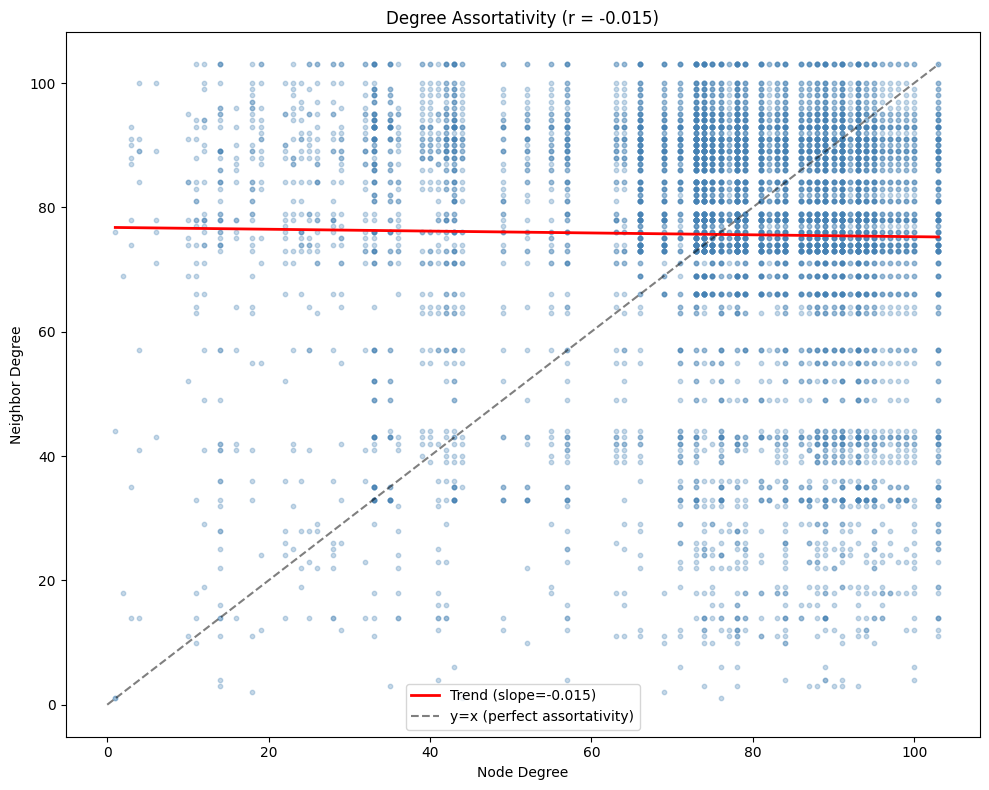

In [37]:
# Calculate degree assortativity
degree_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree Assortativity: {degree_assortativity:.4f}")
# The higher the value, the more likely nodes connect to others with similar degree.

# Get degree of each node and its neighbors
degree_dict = dict(G_connected.degree())

source_degrees = []
target_degrees = []

for u, v in G_connected.edges():
    source_degrees.append(degree_dict[u])
    target_degrees.append(degree_dict[v])
    # Add reverse since undirected
    source_degrees.append(degree_dict[v])
    target_degrees.append(degree_dict[u])

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(source_degrees, target_degrees, alpha=0.3, s=10, color='steelblue')

# Add trend line
z = np.polyfit(source_degrees, target_degrees, 1)
p = np.poly1d(z)
x_line = np.linspace(min(source_degrees), max(source_degrees), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend (slope={z[0]:.3f})')

# Add diagonal reference
max_val = max(max(source_degrees), max(target_degrees))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x (perfect assortativity)')

plt.xlabel('Node Degree')
plt.ylabel('Neighbor Degree')
plt.title(f'Degree Assortativity (r = {degree_assortativity:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('degree_assortativity.png')
plt.show()

# Communities

Detected 18 communities.
[{'size': 45, 'languages': Counter({'TypeScript': 10, 'Python': 7, 'JavaScript': 6, 'Java': 3, 'C#': 3, 'Shell': 3, 'Jupyter Notebook': 2, 'Rust': 2, 'Go': 2, 'Dockerfile': 2, 'C': 1, 'Lua': 1, 'C++': 1, 'Markdown': 1, 'Svelte': 1}), 'dominant_language': 'TypeScript', 'purity': 0.2222222222222222}, {'size': 33, 'languages': Counter({'TypeScript': 11, 'JavaScript': 10, 'C++': 2, 'Vue': 1, 'Batchfile': 1, 'MDX': 1, 'Dart': 1, 'CSS': 1, 'Rich Text Format': 1, 'HTML': 1, 'Rust': 1, 'Python': 1, 'Shell': 1}), 'dominant_language': 'TypeScript', 'purity': 0.3333333333333333}, {'size': 21, 'languages': Counter({'Python': 7, 'Go': 4, 'C++': 3, 'C': 3, 'Scala': 1, 'Rust': 1, 'Vim Script': 1, 'Shell': 1}), 'dominant_language': 'Python', 'purity': 0.3333333333333333}, {'size': 19, 'languages': Counter({'Java': 5, 'Python': 5, 'HTML': 3, 'JavaScript': 2, 'CSS': 1, 'Shell': 1, 'Jupyter Notebook': 1, 'Markdown': 1}), 'dominant_language': 'Java', 'purity': 0.2631578947368421},

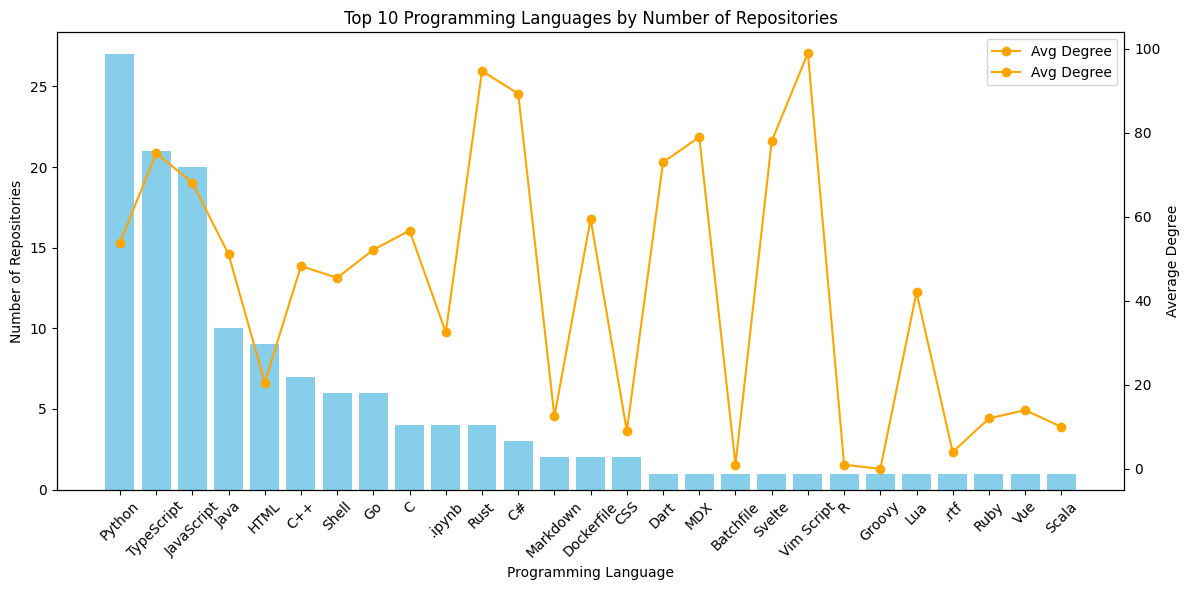


Top programming languages by number of repositories:
  Python: 27 repositories
  TypeScript: 21 repositories
  JavaScript: 20 repositories
  Java: 10 repositories
  HTML: 9 repositories
  C++: 7 repositories
  Shell: 6 repositories
  Go: 6 repositories
  C: 4 repositories
  .ipynb: 4 repositories
  Rust: 4 repositories
  C#: 3 repositories
  Markdown: 2 repositories
  Dockerfile: 2 repositories
  CSS: 2 repositories
  Dart: 1 repositories
  MDX: 1 repositories
  Batchfile: 1 repositories
  Svelte: 1 repositories
  Vim Script: 1 repositories
  R: 1 repositories
  Groovy: 1 repositories
  Lua: 1 repositories
  .rtf: 1 repositories
  Ruby: 1 repositories
  Vue: 1 repositories
  Scala: 1 repositories


In [44]:
community = nx.community.louvain_communities(G, weight='weight')
#g = ig.Graph.TupleList(G.edges(data=True), directed=False, weights=True)
#print(f"Converted to igraph with {g.vcount()} vertices and {g.ecount()} edges.")
#community = g.community_multilevel(weights=g.es['weight'])
print(f"Detected {len(community)} communities.")
sorted_communities = [community for community in community if len(community) > 1]
community_objects = sorted(sorted_communities, key=len, reverse=True)
for i, comm in enumerate(sorted_communities):
    # Find dominant language and purity
    langs = [G.nodes[n].get("language", "Unknown") for n in comm]
    counts = Counter(langs)
    dominant_lang, dominant_count = counts.most_common(1)[0]
    purity = dominant_count / len(comm)
    
    # print(f"\nCommunity {i}:")
    # print(f"  Size: {len(comm)} repos")
    # print(f"  Languages: {counts}")
    # print(f"  Dominant language: {dominant_lang} ({purity:.2%} purity)")

    community_object = {
        "size": len(comm),
        "languages": counts,
        "dominant_language": dominant_lang,
        "purity": purity,
        #"repos": list(comm),
    }

    community_objects[i] = community_object

sorted_communities = sorted(community_objects, key=lambda x: x.get("size", None), reverse=True)
print(sorted_communities[:5])  # Print top 5 communities
#Find average degree based on language
language_degrees = {}
for node, attrs in G.nodes(data=True):
    lang = attrs.get("language", "Unknown")
    if lang == "Jupyter Notebook":
        lang = ".ipynb"
    elif lang == "Rich Text Format":
        lang = ".rtf"
    degree = G.degree(node)
    if lang not in language_degrees:
        language_degrees[lang] = []
    language_degrees[lang].append(degree)

print("\nAverage degree by programming language:")
for lang, degrees in language_degrees.items():
    avg_degree = sum(degrees) / len(degrees)
    print(f"  {lang}: {avg_degree:.2f}")

#Top languages based on number of repos
lang_counter = Counter()
for node, attrs in G.nodes(data=True):
    lang = attrs.get("language", "Unknown")
    if lang == "Jupyter Notebook":
        lang = ".ipynb"
    elif lang == "Rich Text Format":
        lang = ".rtf"
    if lang is not None:
        lang_counter[lang] += 1

#Bar chart showing language popularity with line showing degree for language
plt.figure(figsize=(12, 6))
langs, counts = zip(*lang_counter.most_common(30))
plt.bar(langs, counts, color='skyblue')
plt.xlabel('Programming Language')
plt.ylabel('Number of Repositories')
plt.title('Top 10 Programming Languages by Number of Repositories')
plt.xticks(rotation=45)
ax2 = plt.gca().twinx()
avg_degrees = [np.mean(language_degrees[lang]) for lang in langs]
ax2.plot(langs, avg_degrees, color='orange', marker='o', label='Avg Degree')
ax2.set_ylabel('Average Degree')
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')
plt.tight_layout()
plt.show()

print("\nTop programming languages by number of repositories:")
for lang, count in lang_counter.most_common(30):
    print(f"  {lang}: {count} repositories")



In [49]:
# total amount of autors across al repos
len(language_degrees)


#Total authors.

total_authors = 0
for node, attrs in G.nodes(data=True):
    #print(attrs)
    authors = attrs.get("number_of_collaborators", 0)
    total_authors += authors
print(f"\nTotal unique authors across all repositories: {total_authors}")



Total unique authors across all repositories: 56118
